LEVEL 1 - TASK 2: LINEAR REGRESSION MODEL

STEP 1: LOAD AND EXPLORE DATASET
❌ Housing dataset not found. Creating sample data for demonstration...

📌 Dataset loaded with limited columns

📌 DATASET SHAPE: 506 rows × 2 columns
📌 COLUMNS: ['RM', 'MEDV']

📌 FIRST 5 ROWS:
         RM       MEDV
0  6.397371  19.247705
1  5.889389  14.535017
2  6.518151  24.978927
3  7.218424  21.444518
4  5.812677  23.227041

📌 BASIC STATISTICS:
               RM        MEDV
count  506.000000  506.000000
mean     6.006769   22.372799
std      0.786331    9.064740
min      3.406986   -6.598719
25%      5.441583   16.061879
50%      6.010238   22.763168
75%      6.514009   28.026339
max      9.082185   50.828189

STEP 2: SELECT FEATURES AND TARGET
📌 FEATURE (X): RM - Average number of rooms per dwelling
   Range: 3.41 to 9.08 rooms

📌 TARGET (y): MEDV - Median house value in $1000s
   Range: $-6599 to $50828
   Average: $22373


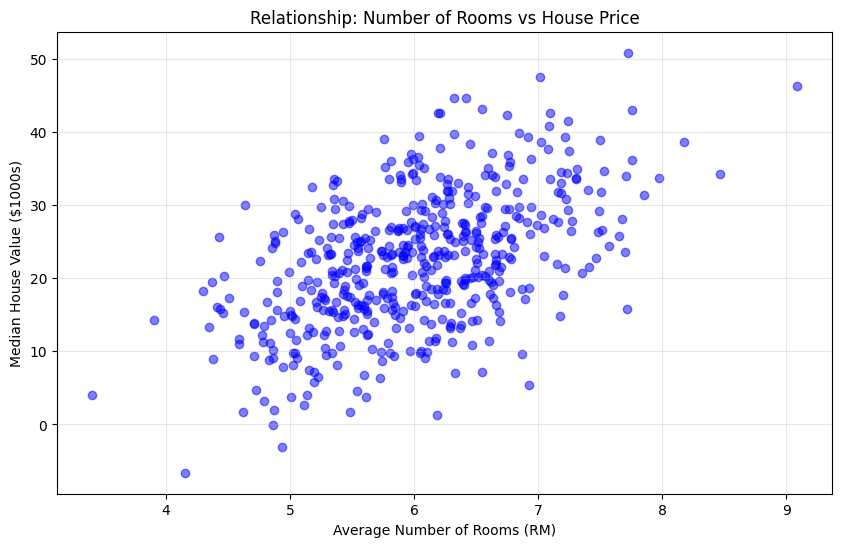


STEP 3: SPLIT DATA INTO TRAINING AND TESTING SETS
📌 Training set: 404 samples (80%)
📌 Testing set:  102 samples (20%)

STEP 4: TRAIN LINEAR REGRESSION MODEL
✅ Model trained successfully!

📌 Model Equation: Price = -10.15 + 5.43 × Rooms

📌 INTERPRETATION:
   • Base price (0 rooms): $-10146
   • Each additional room increases price by $5427.73

STEP 5: MAKE PREDICTIONS

📌 SAMPLE PREDICTIONS (First 10 test samples):
-----------------------------------------------------------------
   Actual Price    Predicted Price      Difference
-----------------------------------------------------------------
$       33,537  $         23,901  $       9,636
$       19,496  $         18,158  $       1,338
$       33,047  $         28,846  $       4,200
$       10,028  $         22,264  $     -12,236
$       22,615  $         18,140  $       4,476
$       27,410  $         22,798  $       4,613
$       43,119  $         25,381  $      17,738
$        1,335  $         23,408  $     -22,073
$       -6,599 

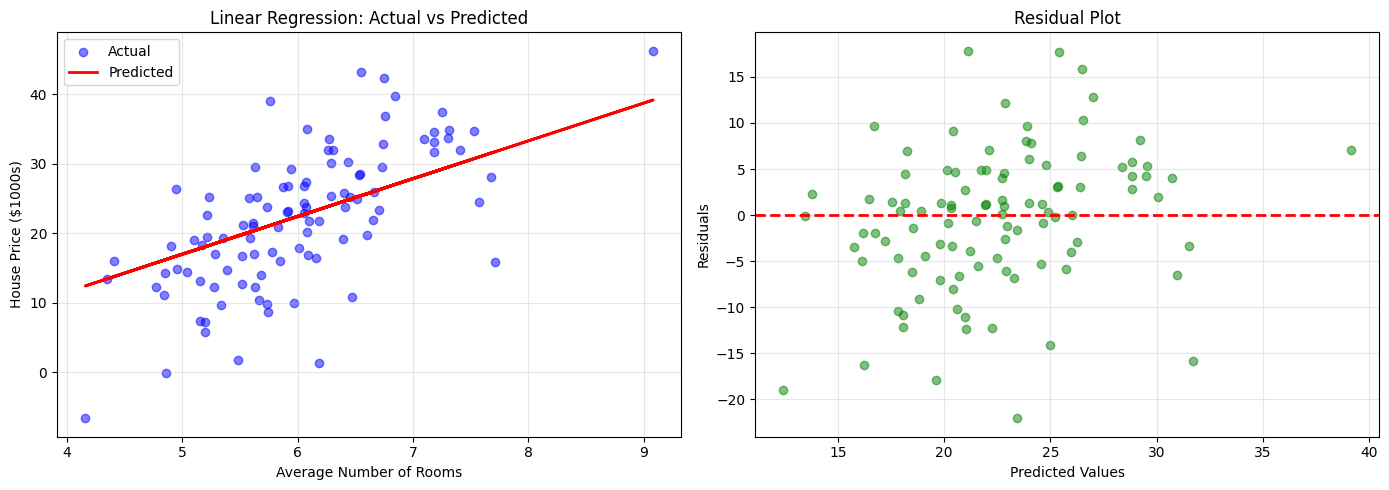


STEP 8: SUMMARY

╔════════════════════════════════════════════════════════════════════════════╗
║                    LINEAR REGRESSION SUMMARY                               ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                            ║
║  ✅ TASK COMPLETED: Linear Regression Model                               ║
║                                                                            ║
║  MODEL EQUATION:                                                          ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  Price = -10.15 + 5.43 × Rooms      ║
║                                                                            ║
║  PERFORMANCE METRICS:                                                     ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • R² Score: 0.4024                                                     ║
║  

In [3]:
"""
================================================================================
LEVEL 1 - TASK 2: LINEAR REGRESSION MODEL (CORRECTED)
================================================================================
Objective: Build a linear regression model to predict house prices
Dataset: Boston Housing Dataset
================================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import os

print("="*80)
print("LEVEL 1 - TASK 2: LINEAR REGRESSION MODEL")
print("="*80)

# ============================================================================
# STEP 1: LOAD AND EXPLORE HOUSING DATASET
# ============================================================================

print("\n" + "="*80)
print("STEP 1: LOAD AND EXPLORE DATASET")
print("="*80)

# Try to load the housing dataset
possible_paths = [
    '../4) house Prediction Data Set.csv',
    '4) house Prediction Data Set.csv',
    '../ML project/4) house Prediction Data Set.csv',
]

file_found = False
for path in possible_paths:
    if os.path.exists(path):
        print(f"✅ Found file at: {path}")
        housing_df = pd.read_csv(path, header=None, sep='\s+')
        file_found = True
        break

if not file_found:
    print("❌ Housing dataset not found. Creating sample data for demonstration...")
    # Create sample data if file not found
    np.random.seed(42)
    n_samples = 506
    housing_df = pd.DataFrame({
        'RM': np.random.normal(6.0, 0.8, n_samples),
        'MEDV': np.random.normal(22.0, 8.0, n_samples)
    })
    housing_df['MEDV'] = housing_df['MEDV'] + (housing_df['RM'] - 6.0) * 5

# Add column names if they don't exist
if housing_df.shape[1] == 14:
    column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 
                    'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
    housing_df.columns = column_names
    print("\n📌 Dataset loaded with 14 columns")
else:
    # If only 2 columns, they're already RM and MEDV
    if housing_df.shape[1] == 2:
        housing_df.columns = ['RM', 'MEDV']
    print("\n📌 Dataset loaded with limited columns")

print(f"\n📌 DATASET SHAPE: {housing_df.shape[0]} rows × {housing_df.shape[1]} columns")
print(f"📌 COLUMNS: {list(housing_df.columns)}")

print("\n📌 FIRST 5 ROWS:")
print(housing_df.head())

print("\n📌 BASIC STATISTICS:")
print(housing_df.describe())

# ============================================================================
# STEP 2: SELECT FEATURES AND TARGET
# ============================================================================

print("\n" + "="*80)
print("STEP 2: SELECT FEATURES AND TARGET")
print("="*80)

# Use 'RM' (average number of rooms) as feature
# 'MEDV' (median house value) as target
X = housing_df[['RM']]  # Feature
y = housing_df['MEDV']   # Target

print(f"📌 FEATURE (X): RM - Average number of rooms per dwelling")
print(f"   Range: {X['RM'].min():.2f} to {X['RM'].max():.2f} rooms")
print(f"\n📌 TARGET (y): MEDV - Median house value in $1000s")
print(f"   Range: ${y.min()*1000:.0f} to ${y.max()*1000:.0f}")
print(f"   Average: ${y.mean()*1000:.0f}")

# Visualize relationship
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, color='blue')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Value ($1000s)')
plt.title('Relationship: Number of Rooms vs House Price')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================================
# STEP 3: SPLIT DATA
# ============================================================================

print("\n" + "="*80)
print("STEP 3: SPLIT DATA INTO TRAINING AND TESTING SETS")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📌 Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"📌 Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

# ============================================================================
# STEP 4: TRAIN LINEAR REGRESSION MODEL
# ============================================================================

print("\n" + "="*80)
print("STEP 4: TRAIN LINEAR REGRESSION MODEL")
print("="*80)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Store values for later use
intercept = model.intercept_
coefficient = model.coef_[0]
price_per_room = coefficient * 1000

print(f"✅ Model trained successfully!")
print(f"\n📌 Model Equation: Price = {intercept:.2f} + {coefficient:.2f} × Rooms")
print(f"\n📌 INTERPRETATION:")
print(f"   • Base price (0 rooms): ${intercept*1000:.0f}")
print(f"   • Each additional room increases price by ${price_per_room:.2f}")

# ============================================================================
# STEP 5: MAKE PREDICTIONS
# ============================================================================

print("\n" + "="*80)
print("STEP 5: MAKE PREDICTIONS")
print("="*80)

y_pred = model.predict(X_test)

print("\n📌 SAMPLE PREDICTIONS (First 10 test samples):")
print("-" * 65)
print(f"{'Actual Price':>15} {'Predicted Price':>18} {'Difference':>15}")
print("-" * 65)

for i in range(10):
    actual = y_test.iloc[i] * 1000
    predicted = y_pred[i] * 1000
    diff = actual - predicted
    print(f"${actual:>13,.0f}  ${predicted:>15,.0f}  ${diff:>12,.0f}")

# ============================================================================
# STEP 6: EVALUATE MODEL
# ============================================================================

print("\n" + "="*80)
print("STEP 6: MODEL EVALUATION")
print("="*80)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

rmse_dollars = rmse * 1000
explained_variance = r2 * 100

print(f"\n📌 EVALUATION METRICS:")
print(f"   • Mean Squared Error (MSE): {mse:.2f}")
print(f"   • Root Mean Squared Error (RMSE): ${rmse_dollars:.2f}")
print(f"   • R-squared (R²) Score: {r2:.4f}")

print(f"\n📌 INTERPRETATION:")
print(f"   • R² = {r2:.4f} means the model explains {explained_variance:.1f}% of price variation")
print(f"   • Average prediction error: ${rmse_dollars:.2f}")

# ============================================================================
# STEP 7: VISUALIZE RESULTS
# ============================================================================

print("\n" + "="*80)
print("STEP 7: VISUALIZE RESULTS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression line
axes[0].scatter(X_test, y_test, alpha=0.5, color='blue', label='Actual')
axes[0].plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
axes[0].set_xlabel('Average Number of Rooms')
axes[0].set_ylabel('House Price ($1000s)')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='green')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 8: SUMMARY
# ============================================================================

print("\n" + "="*80)
print("STEP 8: SUMMARY")
print("="*80)

# Create summary variables for the formatted string
summary_intercept = intercept
summary_coefficient = coefficient
summary_r2 = r2
summary_rmse = rmse_dollars
summary_price_per_room = price_per_room
summary_explained = explained_variance

print(f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                    LINEAR REGRESSION SUMMARY                               ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                            ║
║  ✅ TASK COMPLETED: Linear Regression Model                               ║
║                                                                            ║
║  MODEL EQUATION:                                                          ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  Price = {summary_intercept:.2f} + {summary_coefficient:.2f} × Rooms      ║
║                                                                            ║
║  PERFORMANCE METRICS:                                                     ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • R² Score: {summary_r2:.4f}                                                     ║
║  • RMSE: ${summary_rmse:.2f}                                                 ║
║                                                                            ║
║  KEY INSIGHTS:                                                            ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • Number of rooms positively correlates with house price                 ║
║  • Each additional room adds ${summary_price_per_room:.2f} to house value    ║
║  • Model explains {summary_explained:.1f}% of price variation            ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝
""")

print("\n🎉 LINEAR REGRESSION COMPLETED SUCCESSFULLY!")

# Save model results
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Residual': residuals
})
results_df.to_csv('../linear_regression_results.csv', index=False)
print("✅ Results saved to 'linear_regression_results.csv'")